<center><h1>Numerical linear algebra</h1></center>
<center><h3>The Successive over-relaxation and Conjugate Gradient methods</h3></center>

- - - - - - - - - - - - - - -

In [1]:
import numpy as np
from IPython.display import Image

- - - - - - - - - - - - - - -

Consider a symmetric, positive-definite, tri-diagonal system $Ax = b$ of size $n = 100$ where for $i, j = 1, \dots, n$ we have

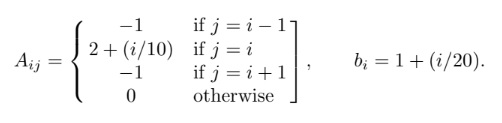

In [2]:
Image('system.jpg')

Use the <b>Conjugate Gradient</b> method with the pre-conditioner $C^{-1} = D^{\frac{1}{2}}$ to solve $Ax = b$ to within a tolerance of $||r^{(k)}||_{\infty} < 10^{-5}$, beginning from an initial guess $x^{(0)} = 0$. Report the approximate solution components $x_{1}^{(k)}, \dots, x_{4}^{(k)}$ and number of iterations $k$ required, and the residual norm $||r^{(k)}||_{\infty}$.

In [3]:
def ConjugateGradient(dim, x, tol = 1e-5):
    A = np.zeros((dim, dim))
    b = [0] * (dim)
    C_inv = np.zeros((dim, dim))

    '''Defining the symmetric, positive-definite, tri-diagonal system above.'''
    for i in range(dim):
        for j in range(dim):
            if (j == i - 1) or (j == i + 1):
                A[i][j] = -1
            elif j == i:
                A[i][j] = (2 + (i + 1) / 10)
            else:
                A[i][j] = 0
        b[i] = (1 + (i + 1) / 20)
    
    for i in range(dim):
        C_inv[i][i] = (1 / np.sqrt(A[i][i]))
        # C_inv[i][i] = 1 # if there is no pre-conditioning
    
    '''The solution is then obtained iteratively as:'''
    '''r_0 := b - Ax_0, p_0 := r_0 and k := 0 if r_0 is sufficiently small, then iterate where'''
    '''alpha_k := (r_k^T * r_k)/(p_k^T * Ap_k)'''
    '''x_k+1 := x_k + alpha_k * p_k'''
    '''r_k+1 := r_k - alpha_k * Ap_k until r_k+1 is sufficiently small'''
    '''beta_k := (r_k+1^T * r_k+1)/(r_k^T * r_k)'''
    '''p_k+1 := r_k+1 + beta_k * p_k'''
    '''where Ap_k, alpha_k * p_k, and beta_k * p_k are all calculated through the dot product.'''
    results = []
    iter = 0
    C_invT = np.transpose(C_inv)

    r = b - (A @ x)
    w = C_inv @ r
    v = C_invT @ w
    alpha = np.dot(w, w)

    while (iter < 500):
        u = A @ v
        t = alpha / (np.dot(v, u))
        x = x + (t * v)
        r = r - (t * u)
        w = C_inv @ r
        beta = np.dot(w, w)
        s = beta / alpha
        v_next = (C_invT @ w) + (s * v)
        alpha = beta
        '''Without ord = np.inf, np.linalg.norm defaults to L2 norm.'''
        error = np.linalg.norm(v - v_next, ord = np.inf)
        if error < tol:
            results.append(x)
            return results, iter, error
        v = v_next
        iter += 1
        
    return results, iter, error

if __name__ == "__main__":
    dim = 100
    guess = [0] * (dim)
    
    results, iter, error = ConjugateGradient(dim, x = guess)

    print(f'Solution converged at |r|_(infinity) = {error}')
    print(f'Iterations needed: k = {iter}')
    print('Approximate solution: x**(k) =')
    print(results)

Solution converged at |r|_(infinity) = 7.017344177283056e-06
Iterations needed: k = 14
Approximate solution: x**(k) =
[array([1.70491269, 2.53031867, 2.76178961, 2.67179723, 2.4505234 ,
       2.20451001, 1.98120005, 1.79472963, 1.6440454 , 1.52300338,
       1.4249654 , 1.34439297, 1.27709247, 1.22000543, 1.17093121,
       1.12824602, 1.09075379, 1.05754185, 1.02790473, 1.00128699,
       0.97724448, 0.95541726, 0.93551022, 0.91727893, 0.90051907,
       0.88505848, 0.87075101, 0.85747175, 0.84511329, 0.83358276,
       0.82279939, 0.81269265, 0.80320064, 0.7942688 , 0.78584887,
       0.77789798, 0.77037796, 0.76325463, 0.75649738, 0.75007867,
       0.74397364, 0.73815982, 0.73261684, 0.7273262 , 0.72227103,
       0.71743594, 0.71280685, 0.70837086, 0.70411614, 0.70003178,
       0.69610776, 0.69233479, 0.68870433, 0.68520844, 0.68183978,
       0.67859151, 0.6754573 , 0.67243124, 0.66950782, 0.66668191,
       0.6639487 , 0.66130371, 0.65874273, 0.65626182, 0.65385728,
       0.6

Repeat the above process using the <b>SOR</b> ($\omega = 1.2$) method and briefly compare results. Begin each method from a zero initial guess and use the same tolerance on the residual. Try the <b>SOR</b> method with different $\omega$ values, say $\omega = 1.6$ and $\omega = 2.3$. Does the value of $\omega$ have a significant impact on convergence? Try <b>Conjugate Gradient</b> without pre-conditioning ($C^{-1} = I$). Does pre-conditioning make a noticeable difference?

#### Successive over-relaxation method
($\omega = 1.2$)

In [4]:
def SOR(dim, x, w, tol = 1e-5):
    A = np.zeros((dim, dim))
    b = [0] * (dim)
    C_inv = np.zeros((dim, dim))

    '''Defining the symmetric, positive-definite, tri-diagonal system above.'''
    for i in range(dim):
        for j in range(dim):
            if (j == i - 1) or (j == i + 1):
                A[i][j] = -1
            elif j == i:
                A[i][j] = (2 + (i + 1) / 10)
            else:
                A[i][j] = 0
        b[i] = (1 + (i + 1) / 20)

    '''This will let us isolate the diagonal of the matrix and turn it into its own matrix.'''
    C = np.diag(A)
    D = np.diagflat(C)

    '''This will construct the pre-conditioned matrix.'''
    for i in range(dim):
        C_inv[i][i] = (1 / np.sqrt(D[i][i]))
        # C_inv[i][i] = 1 # if there is no pre-conditioning
    C = C_inv
    
    '''This gives us the strictly upper and lower matrix components of A.'''
    lower = D - np.tril(A)
    upper = D - np.triu(A)
    
    '''With one of the main components being (D - wL)**-1, this will get the inverse of the matrix.'''
    DwL_inv = np.linalg.inv(D - w * lower)

    '''The solution is then obtained iteratively as:'''
    '''x**(k+1) = (D - wL)**-1 * [wU + (1 - w)D]x + w(D - wL)**-1(b)'''
    '''where [wU + (1 - w)D]x and w(D - wL)**-1(b) are all calculated through the dot product.'''
    results = []
    iter = 0
    
    while (iter < 500):
        x_next = DwL_inv @ ((w * upper + (1 - w) * D) @ x) + (w * DwL_inv @ b)
        '''Without ord = np.inf, np.linalg.norm defaults to L2 norm.'''
        error = np.linalg.norm(x - x_next, ord = np.inf)
        if error < tol:
            results.append(x_next)
            return results, iter, error
        x = x_next
        iter += 1
        
    return results, iter, error

if __name__ == "__main__":
    dim = 100
    guess = [0] * (dim)
    
    results, iter, error = SOR(dim, w = 1.2, x = guess)

    print(f'Solution converged at |r|_(infinity) = {error}')
    print(f'Iterations needed: k = {iter}')
    print('Approximate solution: x**(k) =')
    print(results)

Solution converged at |r|_(infinity) = 6.167775625343097e-06
Iterations needed: k = 16
Approximate solution: x**(k) =
[array([1.70491052, 2.53031616, 2.76178711, 2.67179502, 2.45052118,
       2.20450798, 1.98119955, 1.7947308 , 1.64404667, 1.52300453,
       1.42496693, 1.34439294, 1.27709048, 1.22000566, 1.17092875,
       1.12824496, 1.09075312, 1.05754159, 1.02790491, 1.00128755,
       0.97724531, 0.9554182 , 0.93551115, 0.91727974, 0.90051969,
       0.88505889, 0.87075119, 0.85747173, 0.84511309, 0.8335824 ,
       0.82279892, 0.81269211, 0.80320006, 0.79426822, 0.78584831,
       0.77789746, 0.77037749, 0.76325423, 0.75649706, 0.75007842,
       0.74397347, 0.73815972, 0.73261682, 0.72732624, 0.72227113,
       0.71743609, 0.71280704, 0.70837109, 0.7041164 , 0.70003206,
       0.69610805, 0.6923351 , 0.68870464, 0.68520874, 0.68184007,
       0.67859179, 0.67545757, 0.67243149, 0.66950805, 0.66668212,
       0.66394889, 0.66130387, 0.65874287, 0.65626193, 0.65385737,
       0.6

#### Successive over-relaxation method
($\omega = 1.6$)

In [5]:
results, iter, error = SOR(dim, w = 1.6, x = guess)

print(f'Solution converged at |r|_(infinity) = {error}')
print(f'Iterations needed: k = {iter}')
print('Approximate solution: x**(k) =')
print(results)

Solution converged at |r|_(infinity) = 6.961080466938441e-06
Iterations needed: k = 25
Approximate solution: x**(k) =
[array([1.70491457, 2.53032017, 2.76178894, 2.67179484, 2.45052085,
       2.20450849, 1.98120033, 1.79473116, 1.64404668, 1.52300452,
       1.42496697, 1.34439294, 1.27709043, 1.22000563, 1.17092876,
       1.12824499, 1.09075312, 1.05754157, 1.0279049 , 1.00128756,
       0.97724531, 0.95541821, 0.93551115, 0.91727973, 0.90051969,
       0.88505889, 0.8707512 , 0.85747173, 0.84511309, 0.8335824 ,
       0.82279892, 0.81269211, 0.80320006, 0.79426822, 0.78584831,
       0.77789746, 0.77037749, 0.76325423, 0.75649706, 0.75007842,
       0.74397347, 0.73815972, 0.73261682, 0.72732624, 0.72227113,
       0.71743609, 0.71280704, 0.70837109, 0.7041164 , 0.70003206,
       0.69610805, 0.69233509, 0.68870463, 0.68520874, 0.68184007,
       0.67859179, 0.67545757, 0.67243149, 0.66950805, 0.66668211,
       0.66394888, 0.66130387, 0.65874286, 0.65626193, 0.65385736,
       0.6

#### Successive over-relaxation method
($\omega = 2.3$)

In [6]:
results, iter, error = SOR(dim, w = 2.3, x = guess)

print(f'Solution converged at |r|_(infinity) = {error}')
print(f'Iterations needed: k = {iter}')
print('Approximate solution: x**(k) =')
print(results)

Solution converged at |r|_(infinity) = 1.1169131137172364e+62
Iterations needed: k = 500
Approximate solution: x**(k) =
[]


For the <b>Conjugate Gradient</b> method, pre-conditioning changed the amount of iterations it needed to converge. This was not exactly true for the <b>Successive over-relaxation</b> method. The biggest difference maker was changing the weights. Changing the weights really impacted its convergence, and when $\omega = 1.2$ jumped to $\omega = 1.6$, it needed another 9 iterations to converge. When that weight was changed to $\omega = 2.3$, it would not even converge after 500 iterations.

## Further readings:
Reading material:<br>
https://www.amazon.com/Numerical-Analysis-Richard-L-Burden/dp/1305253663/

The @ symbol: <br>
https://stackoverflow.com/questions/6392739/what-does-the-at-symbol-do-in-python

## Useful links:
Quick definitions:<br>
https://mathworld.wolfram.com/SuccessiveOverrelaxationMethod.html <br>
https://mathworld.wolfram.com/ConjugateGradientMethod.html